# ARTI 502 – Deep Learning: 1st Assignment
## Training-Testing a Neural Net on the MNIST Dataset using PyTorch
**Imam Abdulrahman Bin Faisal University – CCSIT · Year 2026, Term 1 · Group 1**

GitHub repository: [https://github.com/KhalidExe/ARTI502-Assignment1](https://github.com/KhalidExe/ARTI502-Assignment1)

| Section | Content |
|---|---|
| Task 1 | Install & load PyTorch |
| Task 2 | Download & load MNIST (50k train / 10k validation / 10k test) |
| Task 3 | Inspect the dataset (tensor sizes, sample images, class balance) |
| Task 4 | Simple network – one hidden layer + ReLU, `torch.flatten` |
| Task 5 | Training function (CrossEntropyLoss + SGD with learning rate & momentum) |
| Task 6 | Train the network (debug log + loss/accuracy graphs) |
| Task 7 | Test the network |
| Task 8 | Tune learning rate / momentum and the architecture (layers × neurons) |
| Task 9 | Save the source code & best model |
| Beyond Requirements | CNN, Dropout/BatchNorm, LR scheduler + early stopping, CPU vs GPU, comparison |
| Hardware & Environment | Machine specs and training times |

**Protocol:** all hyper-parameters are chosen on the **validation** split only; the test split is used for reporting.

---
# Task 1: Install PyTorch
PyTorch is installed in a project virtual environment (`.venv`, Python 3.14) from the **official PyTorch wheel index**.
The RTX 50-series (Blackwell) GPU needs a CUDA 12.8-or-newer build; the latest stable release (torch 2.14.0) is published
for CUDA 13.0, so `requirements.txt` pins `torch==2.14.0+cu130` from `https://download.pytorch.org/whl/cu130`.
Equivalent command:

```
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
```
The first cell installs everything from `requirements.txt` (already-installed packages are skipped).
The next cell loads PyTorch and the related libraries, prints their versions, verifies the GPU,
and fixes all random seeds so every result in this notebook is reproducible.

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # needed for deterministic cuBLAS

import math, time, random, platform, sys, copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"CUDA build  : {torch.version.cuda}")
print(f"CUDA ready  : {torch.cuda.is_available()}")

Python      : 3.14.4
PyTorch     : 2.14.0+cu130
torchvision : 0.29.0+cu130
NumPy       : 2.5.3
pandas      : 3.0.6
matplotlib  : 3.11.2
CUDA build  : 13.0
CUDA ready  : True


In [3]:
# ---- GPU verification --------------------------------------------------------
assert torch.cuda.is_available(), "CUDA GPU not available - stop here"
DEVICE = torch.device("cuda")
print("GPU name        :", torch.cuda.get_device_name(0))
print("Compute cap.    :", torch.cuda.get_device_capability(0))
a = torch.randn(1000, 1000, device=DEVICE)
b = torch.randn(1000, 1000, device=DEVICE)
c = a @ b
torch.cuda.synchronize()
print("Tensor op on GPU:", c.shape, "| device:", c.device, "| checksum:", round(c.sum().item(), 3))

# ---- reproducibility -------------------------------------------------------------
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

# ---- output folders + helpers -------------------------------------------------------
os.makedirs("screenshots", exist_ok=True)
os.makedirs("models", exist_ok=True)
def save_fig(name):
    path = os.path.join("screenshots", name)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("saved ->", path)

TIMINGS = []   # (model, device, epochs, seconds) - filled by every training run
print("Seed:", SEED, "| deterministic cuDNN:", torch.backends.cudnn.deterministic)

GPU name        : NVIDIA GeForce RTX 5070 Ti
Compute cap.    : (12, 0)
Tensor op on GPU: torch.Size([1000, 1000]) | device: cuda:0 | checksum: -24264.48
Seed: 42 | deterministic cuDNN: True


**Result:**

PyTorch **2.14.0+cu130** (CUDA 13.0 build) and torchvision 0.29.0 are loaded in Python 3.14.4.
`torch.cuda.is_available()` is **True**, the GPU is detected as **NVIDIA GeForce RTX 5070 Ti** with compute capability 12.0 (Blackwell),
and a 1000×1000 matrix multiplication runs on `cuda:0` – so the CUDA build works on this GPU.
With seed 42 and deterministic cuDNN every run is reproducible (for example, the 1×512 configuration gives exactly the same
validation result in Task 8a and Task 8b).

---
# Task 2: Download and Load the Dataset
`torchvision.datasets.MNIST` downloads the dataset from code into `./data`.
The official 60,000 training images are split (with a fixed seed) into **50,000 training** images
(the number stated in the assignment) and **10,000 validation** images; the official **10,000 test** images are kept untouched.
Images are converted to tensors and normalised with the MNIST mean/std (0.1307, 0.3081).

In [4]:
MEAN, STD = 0.1307, 0.3081
transform = transforms.Compose([
    transforms.ToTensor(),                     # uint8 [0,255] -> float [0,1], shape 1x28x28
    transforms.Normalize((MEAN,), (STD,)),
])

full_train = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_set, val_set = random_split(full_train, [50_000, 10_000],
                                  generator=torch.Generator().manual_seed(SEED))

print(f"Full official training set : {len(full_train):>6}")
print(f"  -> training subset        : {len(train_set):>6}")
print(f"  -> validation subset      : {len(val_set):>6}")
print(f"Official test set           : {len(test_set):>6}")
print("Classes:", full_train.classes)

Full official training set :  60000
  -> training subset        :  50000
  -> validation subset      :  10000
Official test set           :  10000
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


**Result:**

MNIST was downloaded from code into `./data`. The 60,000 official training images were split into **50,000 training** and
**10,000 validation** images (fixed seed), and the **10,000 official test** images are kept separate for the final evaluation.
There are 10 classes (digits 0–9).

---
# Task 3: Inspect the Dataset
A standard `DataLoader` with a mini-batch size of 32 is used to see how images are loaded into tensors.

In [5]:
BATCH_SIZE = 32
train_loader_std = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                              generator=torch.Generator().manual_seed(SEED))
images, labels = next(iter(train_loader_std))

print("1) Images tensor size :", images.size())      # N x C x H x W
print("   Labels tensor size :", labels.size())
print("   dtype / value range :", images.dtype, f"[{images.min():.3f}, {images.max():.3f}]")
print("   Batches per epoch   :", len(train_loader_std))

1) Images tensor size : torch.Size([32, 1, 28, 28])
   Labels tensor size : torch.Size([32])
   dtype / value range : torch.float32 [-0.424, 2.821]
   Batches per epoch   : 1563


**Result:**

1. **Images tensor size = `[32, 1, 28, 28]`** = N × C × H × W: 32 images per mini-batch, 1 grayscale (colour) channel, 28×28 pixels.
   The labels tensor is `[32]` (one digit per image).
* After normalisation the pixel values range from −0.424 (black background) to 2.821 (white strokes).
* With batch size 32, the 50,000 training images give **1,563 mini-batches per epoch** (the last one has 16 images).

saved -> screenshots\task03_samples.png


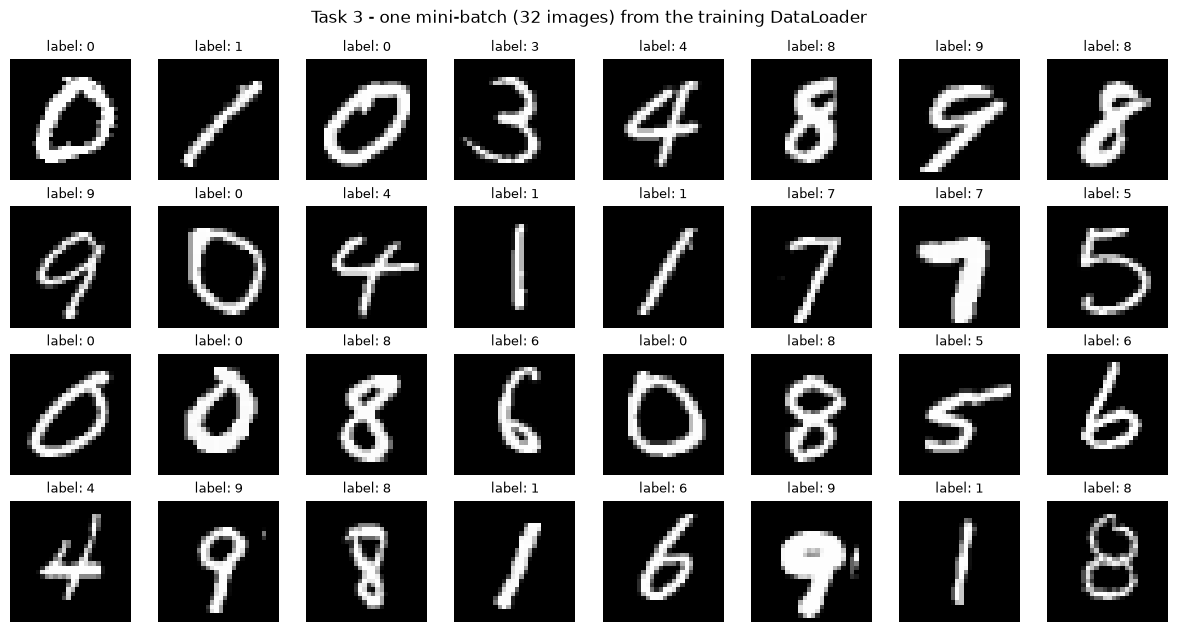

In [6]:
# 2) Visualise a batch with matplotlib (un-normalise for display)
fig, axes = plt.subplots(4, 8, figsize=(12, 6.4))
for ax, img, lab in zip(axes.flat, images, labels):
    ax.imshow((img.squeeze() * STD + MEAN).numpy(), cmap="gray")
    ax.set_title(f"label: {lab.item()}", fontsize=9)
    ax.axis("off")
fig.suptitle("Task 3 - one mini-batch (32 images) from the training DataLoader")
plt.tight_layout(); save_fig("task03_samples.png"); plt.show()

saved -> screenshots\task03_class_distribution.png


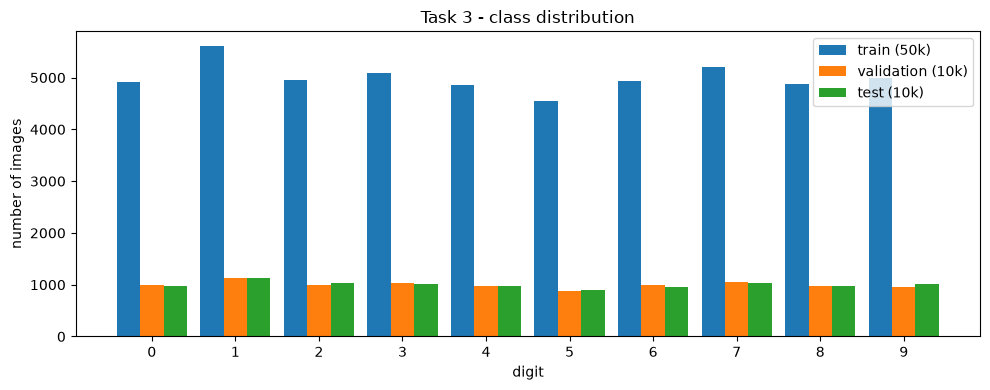

          0     1     2     3     4     5     6     7     8     9
train  4923  5613  4958  5093  4863  4546  4933  5204  4882  4985
val    1000  1129  1000  1038   979   875   985  1061   969   964
test    980  1135  1032  1010   982   892   958  1028   974  1009


In [7]:
# Class distribution of the three splits
train_counts = torch.bincount(full_train.targets[train_set.indices], minlength=10).numpy()
val_counts   = torch.bincount(full_train.targets[val_set.indices],   minlength=10).numpy()
test_counts  = torch.bincount(test_set.targets, minlength=10).numpy()

x = np.arange(10); w = 0.28
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w, train_counts, w, label="train (50k)")
ax.bar(x,     val_counts,   w, label="validation (10k)")
ax.bar(x + w, test_counts,  w, label="test (10k)")
ax.set_xticks(x); ax.set_xlabel("digit"); ax.set_ylabel("number of images")
ax.set_title("Task 3 - class distribution"); ax.legend()
plt.tight_layout(); save_fig("task03_class_distribution.png"); plt.show()

print(pd.DataFrame({"train": train_counts, "val": val_counts, "test": test_counts}, index=range(10)).T)

**Result:**

2. The matplotlib grid shows one real mini-batch of handwritten digits with their labels.
The classes are roughly balanced: in the training split the smallest class is digit 5 (4,546 images) and the largest is digit 1 (5,613);
validation and test follow the same pattern, so accuracy is a fair metric for this dataset.

### Fast GPU data pipeline (used from Task 5 onwards)
MNIST is tiny (≈ 180 MB as float32), so all splits are normalised **once** and kept on the GPU.
`GPUBatchLoader` then yields mini-batches by indexing GPU tensors – same data and same normalisation as the
`DataLoader` above, but without per-batch CPU→GPU copies (and without Windows `num_workers` issues).

In [8]:
def to_tensor(dataset_targets_data, idx=None):
    data, targets = dataset_targets_data
    if idx is not None:
        data, targets = data[idx], targets[idx]
    x = (data.float().div(255.) - MEAN) / STD
    return x.unsqueeze(1), targets.clone()

tr_idx, va_idx = torch.tensor(train_set.indices), torch.tensor(val_set.indices)
X_train, y_train = to_tensor((full_train.data, full_train.targets), tr_idx)
X_val,   y_val   = to_tensor((full_train.data, full_train.targets), va_idx)
X_test,  y_test  = to_tensor((test_set.data,   test_set.targets))

# sanity check: identical to what the torchvision transform produces
assert torch.allclose(X_train[0], train_set[0][0], atol=1e-6) and y_train[0] == train_set[0][1]

X_train, y_train = X_train.to(DEVICE), y_train.to(DEVICE)
X_val,   y_val   = X_val.to(DEVICE),   y_val.to(DEVICE)
X_test,  y_test  = X_test.to(DEVICE),  y_test.to(DEVICE)

class GPUBatchLoader:
    """Minimal DataLoader replacement over tensors that already live on the GPU."""
    def __init__(self, X, y, batch_size=32, shuffle=True, seed=SEED):
        self.X, self.y, self.batch_size, self.shuffle = X, y, batch_size, shuffle
        self.gen = torch.Generator().manual_seed(seed)
    def __len__(self):
        return math.ceil(len(self.X) / self.batch_size)
    def __iter__(self):
        n = len(self.X)
        idx = torch.randperm(n, generator=self.gen) if self.shuffle else torch.arange(n)
        idx = idx.to(self.X.device)
        for i in range(0, n, self.batch_size):
            b = idx[i:i + self.batch_size]
            yield self.X[b], self.y[b]

def make_loaders(batch_size=BATCH_SIZE, seed=SEED):
    return (GPUBatchLoader(X_train, y_train, batch_size, True, seed),
            GPUBatchLoader(X_val,   y_val,   1024, False),
            GPUBatchLoader(X_test,  y_test,  1024, False))

train_loader, val_loader, test_loader = make_loaders()
print("GPU tensors:", tuple(X_train.shape), tuple(X_val.shape), tuple(X_test.shape), "on", X_train.device)
print("Train batches per epoch:", len(train_loader))

GPU tensors: (50000, 1, 28, 28) (10000, 1, 28, 28) (10000, 1, 28, 28) on cuda:0
Train batches per epoch: 1563


---
# Task 4: Creating a Simple Network
One fully connected layer maps the 784 inputs to the hidden neurons, **ReLU** is applied to the hidden values,
and a second fully connected layer maps the hidden neurons to the 10 output classes:

`input (N×1×28×28) → torch.flatten → (N×784) → Linear(784→512) → ReLU → Linear(512→10) → logits (N×10)`

`nn.Linear` expects a 2-D input *N × I*, so `torch.flatten(x, 1)` keeps the batch dimension N and merges C×H×W = 1×28×28 = 784.

In [9]:
class SimpleNet(nn.Module):
    def __init__(self, inputs=28 * 28, hidden=512, outputs=10):
        super().__init__()
        self.fc1 = nn.Linear(inputs, hidden)    # input  -> hidden
        self.fc2 = nn.Linear(hidden, outputs)   # hidden -> output

    def forward(self, x):
        x = torch.flatten(x, 1)                 # (N,1,28,28) -> (N,784)
        x = F.relu(self.fc1(x))                 # ReLU non-linearity on hidden neurons
        x = self.fc2(x)                         # raw scores (logits); softmax is inside CrossEntropyLoss
        return x

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

set_seed()
net = SimpleNet()
print(net)
print(f"Trainable parameters: {count_params(net):,}  (784*512+512 + 512*10+10)")

SimpleNet(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
Trainable parameters: 407,050  (784*512+512 + 512*10+10)


In [10]:
# Verify the shapes with one real mini-batch from the Task 3 DataLoader
print("batch before flatten :", tuple(images.shape))
flat = torch.flatten(images, 1)
print("batch after  flatten :", tuple(flat.shape))
with torch.no_grad():
    hidden = F.relu(net.fc1(flat))
    out = net(images)
print("hidden layer output  :", tuple(hidden.shape))
print("network output       :", tuple(out.shape))
assert flat.shape == (32, 784) and out.shape == (32, 10)
print("Shape check passed: (32 x 1 x 28 x 28) -> (32 x 784) -> (32 x 10)")

batch before flatten : (32, 1, 28, 28)
batch after  flatten : (32, 784)
hidden layer output  : (32, 512)
network output       : (32, 10)
Shape check passed: (32 x 1 x 28 x 28) -> (32 x 784) -> (32 x 10)


**Result:**

The network matches the required structure: `fc1` 784→512, **ReLU**, `fc2` 512→10, with **407,050** trainable parameters
(784·512 + 512 = 401,920 and 512·10 + 10 = 5,130).
Running a real batch verifies the shapes: **(32 × 1 × 28 × 28) → `torch.flatten` → (32 × 784)** → hidden layer (32 × 512) → output (32 × 10),
i.e. one score (logit) per class for each image.

---
# Task 5: Training Function
`train(net, train_loader, ...)` takes the network and the training data loader plus optional parameters
(epochs, learning rate, momentum, weight decay, validation loader, print interval).

* **Loss:** `nn.CrossEntropyLoss` – applies log-softmax to the network outputs and minimises the negative log-likelihood of the correct class (i.e. maximises the likelihood).
* **Optimizer:** `torch.optim.SGD` with **learning rate** and **momentum**.
* **Debug output:** every `print_every` batches it prints epoch, batch number, current (running) loss and accuracy.
* **Returns:** the list of **all mini-batch losses**, plus a history dict with per-epoch train/validation loss & accuracy.

In [11]:
@torch.no_grad()
def evaluate(net, loader, return_preds=False):
    """Average loss and accuracy (%) of `net` over `loader`."""
    net.eval()
    crit = nn.CrossEntropyLoss(reduction="sum")
    loss_sum, correct, n, preds = 0.0, 0, 0, []
    for xb, yb in loader:
        out = net(xb)
        loss_sum += crit(out, yb).item()
        p = out.argmax(1)
        correct += (p == yb).sum().item(); n += yb.numel()
        if return_preds: preds.append(p)
    res = (loss_sum / n, 100.0 * correct / n)
    return res + (torch.cat(preds),) if return_preds else res


def train(net, train_loader, epochs=1, lr=0.01, momentum=0.9, weight_decay=0.0,
          val_loader=None, print_every=250, verbose=True, name="model"):
    net.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    losses = []                                        # every mini-batch loss
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    t0 = time.perf_counter()
    for epoch in range(epochs):
        net.train()
        ep_losses, ep_correct, ep_n = [], torch.zeros((), device=DEVICE), 0
        win_loss, win_correct, win_n = 0.0, 0, 0
        for i, (xb, yb) in enumerate(train_loader):
            optimizer.zero_grad(set_to_none=True)
            out = net(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            correct = (out.argmax(1) == yb).sum()
            ep_losses.append(loss.detach()); ep_correct += correct; ep_n += yb.numel()
            if verbose and (i + 1) % print_every == 0:          # debug information
                recent = torch.stack(ep_losses[-print_every:]).mean().item()
                acc = 100.0 * ep_correct.item() / ep_n
                print(f"epoch {epoch+1:>2}/{epochs} | batch {i+1:>5}/{len(train_loader)} "
                      f"| loss {recent:.4f} | running acc {acc:6.2f}%")
        ep_losses = torch.stack(ep_losses).cpu()
        losses.extend(ep_losses.tolist())
        tr_loss, tr_acc = ep_losses.mean().item(), 100.0 * ep_correct.item() / ep_n
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        if val_loader is not None:
            v_loss, v_acc = evaluate(net, val_loader)
            history["val_loss"].append(v_loss); history["val_acc"].append(v_acc)
        if verbose:
            msg = f"==> epoch {epoch+1:>2} done | train loss {tr_loss:.4f} acc {tr_acc:6.2f}%"
            if val_loader is not None:
                msg += f" | val loss {v_loss:.4f} acc {v_acc:6.2f}%"
            print(msg)
        if not math.isfinite(tr_loss):                   # diverged (too large lr) -> stop early
            if verbose: print("loss diverged - stopping")
            break
    torch.cuda.synchronize()
    history["time_s"] = time.perf_counter() - t0
    TIMINGS.append({"model": name, "device": str(DEVICE), "epochs": epochs, "seconds": history["time_s"]})
    return losses, history

print("train() and evaluate() defined")

train() and evaluate() defined


---
# Task 6: Training the Network
A **new** `SimpleNet` (784 → 512 → 10) is instantiated and trained on the 50,000 training images with
mini-batch size 32, **10 epochs, learning rate 0.01, momentum 0.9**. The validation split is evaluated after every epoch.

In [12]:
EPOCHS, LR, MOMENTUM = 10, 0.01, 0.9
set_seed()
net = SimpleNet()
train_loader, val_loader, test_loader = make_loaders()
losses, hist = train(net, train_loader, epochs=EPOCHS, lr=LR, momentum=MOMENTUM,
                     val_loader=val_loader, print_every=250, name="SimpleNet baseline (Task 6)")
print(f"\nTraining time: {hist['time_s']:.1f} s | mini-batch losses recorded: {len(losses)}")

epoch  1/10 | batch   250/1563 | loss 0.4823 | running acc  84.91%
epoch  1/10 | batch   500/1563 | loss 0.2408 | running acc  88.94%
epoch  1/10 | batch   750/1563 | loss 0.2040 | running acc  90.60%
epoch  1/10 | batch  1000/1563 | loss 0.1529 | running acc  91.81%
epoch  1/10 | batch  1250/1563 | loss 0.1350 | running acc  92.61%
epoch  1/10 | batch  1500/1563 | loss 0.1302 | running acc  93.19%
==> epoch  1 done | train loss 0.2197 acc  93.34% | val loss 0.1205 acc  96.44%
epoch  2/10 | batch   250/1563 | loss 0.0888 | running acc  97.51%
epoch  2/10 | batch   500/1563 | loss 0.0844 | running acc  97.35%
epoch  2/10 | batch   750/1563 | loss 0.0954 | running acc  97.28%
epoch  2/10 | batch  1000/1563 | loss 0.0769 | running acc  97.42%
epoch  2/10 | batch  1250/1563 | loss 0.0749 | running acc  97.46%
epoch  2/10 | batch  1500/1563 | loss 0.0761 | running acc  97.49%
==> epoch  2 done | train loss 0.0830 acc  97.49% | val loss 0.0901 acc  97.19%
epoch  3/10 | batch   250/1563 | los

**Result:**

The debug log prints the **epoch, batch number, loss** (mean of the last 250 mini-batches) and **running accuracy**, plus a summary
after every epoch. The mean training loss falls from 0.2197 (epoch 1) to 0.0025 (epoch 10) and training accuracy reaches 99.98%.
Validation accuracy rises from 96.44% to a peak of **97.99%** (epoch 7) and ends at **97.92%** (val loss 0.0727).
Training 10 epochs took 13.3 s on the GPU and the function returned all **15,630 mini-batch losses**.

saved -> screenshots\task06_minibatch_loss.png


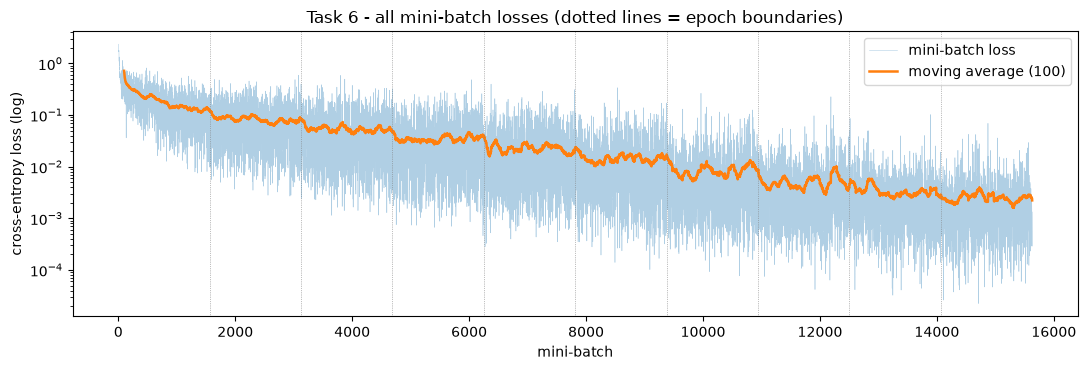

saved -> screenshots\task06_epoch_curves.png


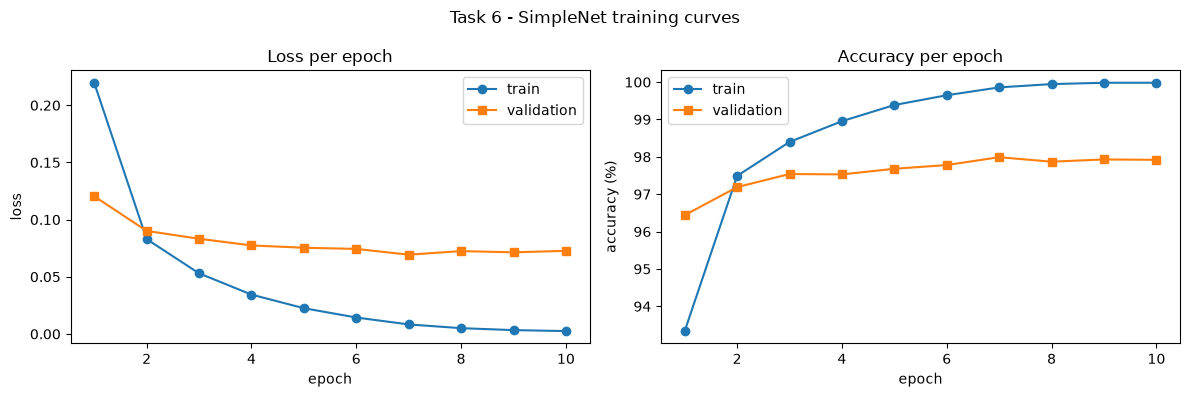

    train_loss  train_acc  val_loss  val_acc
1       0.2197     93.338    0.1205    96.44
2       0.0830     97.490    0.0901    97.19
3       0.0530     98.398    0.0833    97.54
4       0.0344     98.954    0.0774    97.53
5       0.0225     99.386    0.0754    97.68
6       0.0144     99.648    0.0744    97.78
7       0.0083     99.858    0.0693    97.99
8       0.0050     99.946    0.0725    97.87
9       0.0033     99.982    0.0714    97.93
10      0.0025     99.982    0.0727    97.92


In [13]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(losses, lw=0.4, alpha=0.35, label="mini-batch loss")
k = 100
ax.plot(np.arange(k - 1, len(losses)), np.convolve(losses, np.ones(k) / k, mode="valid"), lw=1.8, label=f"moving average ({k})")
for e in range(1, EPOCHS):
    ax.axvline(e * len(train_loader), color="gray", lw=0.5, ls=":")
ax.set_yscale("log"); ax.set_xlabel("mini-batch"); ax.set_ylabel("cross-entropy loss (log)")
ax.set_title("Task 6 - all mini-batch losses (dotted lines = epoch boundaries)"); ax.legend()
plt.tight_layout(); save_fig("task06_minibatch_loss.png"); plt.show()

ep = np.arange(1, len(hist["train_loss"]) + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(ep, hist["train_loss"], "o-", label="train"); a1.plot(ep, hist["val_loss"], "s-", label="validation")
a1.set_title("Loss per epoch"); a1.set_xlabel("epoch"); a1.set_ylabel("loss"); a1.legend()
a2.plot(ep, hist["train_acc"], "o-", label="train"); a2.plot(ep, hist["val_acc"], "s-", label="validation")
a2.set_title("Accuracy per epoch"); a2.set_xlabel("epoch"); a2.set_ylabel("accuracy (%)"); a2.legend()
fig.suptitle("Task 6 - SimpleNet training curves")
plt.tight_layout(); save_fig("task06_epoch_curves.png"); plt.show()

print(pd.DataFrame(hist, index=ep).drop(columns="time_s").round(4).to_string())

**Result:**

* **Mini-batch losses:** the loss drops fast during the first epoch and keeps decreasing (log scale) with noise, because each point is a single batch of 32 images.
* **Per-epoch curves:** training loss keeps going towards 0, but the validation loss reaches its minimum (0.0693) at epoch 7 and then rises slightly to 0.0727,
  while training accuracy is ≈100 %. The ≈2-point gap between training (99.98 %) and validation (97.92 %) accuracy shows the network starts to **overfit** after ~7 epochs.

---
# Task 7: Testing the Network
The trained Task 6 network is evaluated on the **10,000 unseen test images** (from Task 2).

Test loss    : 0.0603
Test accuracy: 98.26%  (9826 / 10000 correct)
saved -> screenshots\task07_test_predictions.png


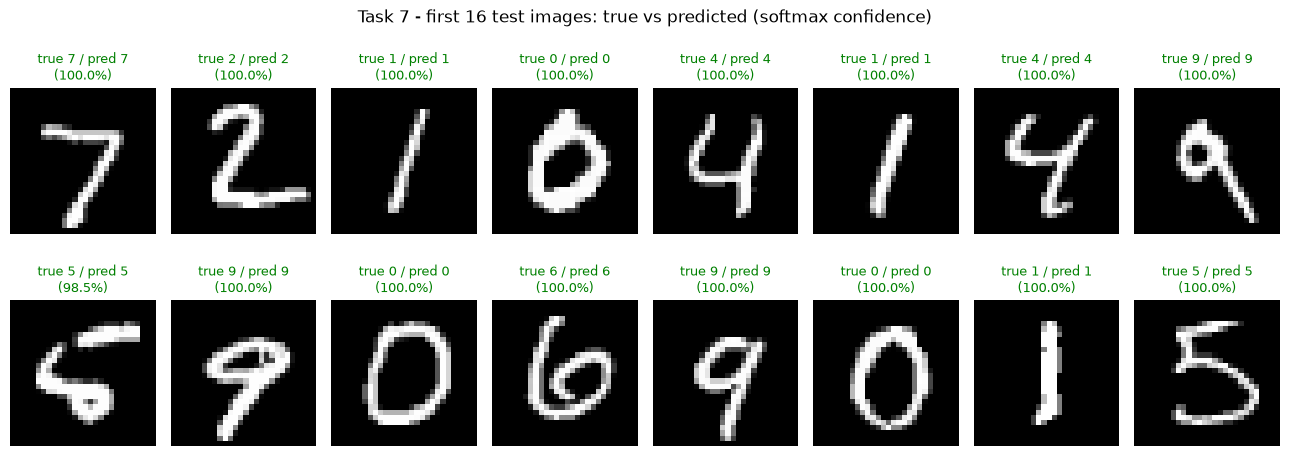

In [14]:
test_loss, test_acc, test_preds = evaluate(net, test_loader, return_preds=True)
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2f}%  ({(test_preds == y_test).sum().item()} / {len(y_test)} correct)")

# a few test images: true vs predicted label
Xs = X_test[:16]
with torch.no_grad():
    probs = F.softmax(net(Xs), dim=1)
conf, pred = probs.max(1)
fig, axes = plt.subplots(2, 8, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow((Xs[i, 0] * STD + MEAN).cpu(), cmap="gray"); ax.axis("off")
    ok = pred[i].item() == y_test[i].item()
    ax.set_title(f"true {y_test[i].item()} / pred {pred[i].item()}\n({100*conf[i].item():.1f}%)",
                 fontsize=9, color="green" if ok else "red")
fig.suptitle("Task 7 - first 16 test images: true vs predicted (softmax confidence)")
plt.tight_layout(h_pad=1.5); save_fig("task07_test_predictions.png"); plt.show()

**Result:**

On the 10,000 unseen test images the Task 6 network reaches **test loss 0.0603** and **test accuracy 98.26 %** (9,826 correct).
All 16 test images shown are predicted correctly (green); 15 of them with ≈100 % softmax confidence and the slanted “5” with 98.5 %.

saved -> screenshots\task07_confusion_matrix.png


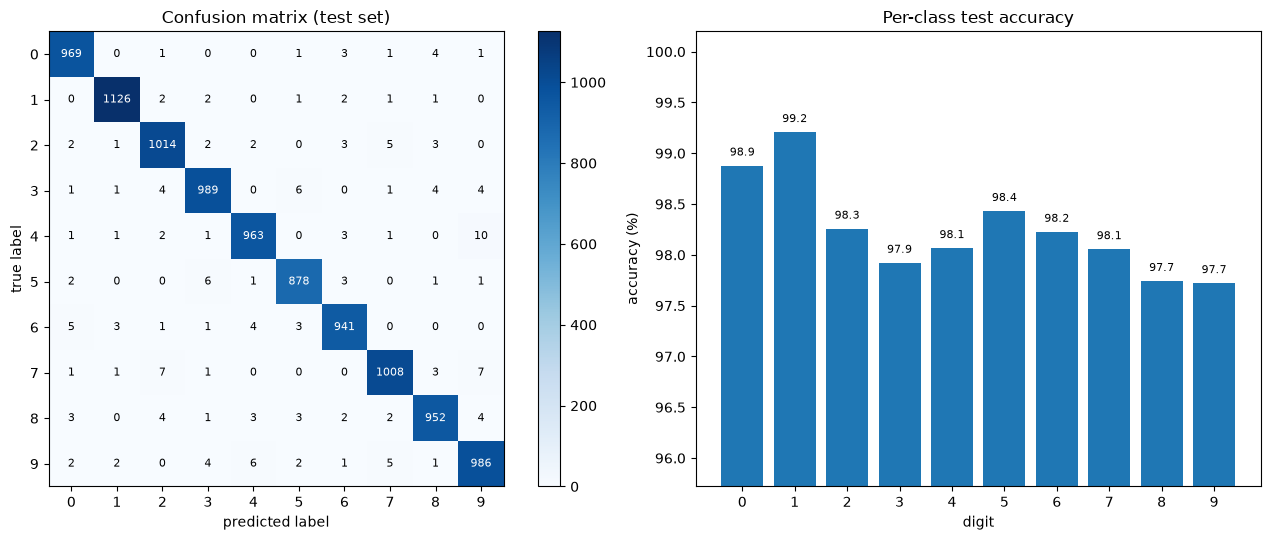

                 0        1        2        3       4       5       6        7       8        9
correct     969.00  1126.00  1014.00   989.00  963.00  878.00  941.00  1008.00  952.00   986.00
total       980.00  1135.00  1032.00  1010.00  982.00  892.00  958.00  1028.00  974.00  1009.00
accuracy %   98.88    99.21    98.26    97.92   98.07   98.43   98.23    98.05   97.74    97.72
Most frequent confusions (true -> predicted): [(4, 9, 10), (7, 9, 7), (7, 2, 7)]


In [15]:
cm = torch.bincount(y_test * 10 + test_preds, minlength=100).reshape(10, 10).cpu().numpy()
per_class = 100 * cm.diagonal() / cm.sum(1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.2, 1]})
im = a1.imshow(cm, cmap="Blues")
for i in range(10):
    for j in range(10):
        a1.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
a1.set_xticks(range(10)); a1.set_yticks(range(10))
a1.set_xlabel("predicted label"); a1.set_ylabel("true label"); a1.set_title("Confusion matrix (test set)")
fig.colorbar(im, ax=a1, fraction=0.046)
a2.bar(range(10), per_class, color="tab:blue")
a2.set_ylim(per_class.min() - 2, 100.2); a2.set_xticks(range(10))
for i, v in enumerate(per_class):
    a2.text(i, v + 0.1, f"{v:.1f}", ha="center", fontsize=8)
a2.set_xlabel("digit"); a2.set_ylabel("accuracy (%)"); a2.set_title("Per-class test accuracy")
plt.tight_layout(); save_fig("task07_confusion_matrix.png"); plt.show()

print(pd.DataFrame({"correct": cm.diagonal(), "total": cm.sum(1), "accuracy %": per_class.round(2)}).T.to_string())
off = cm.copy(); np.fill_diagonal(off, 0)
top = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:3], off.shape))[0]
print("Most frequent confusions (true -> predicted):", [(int(t), int(p), int(off[t, p])) for t, p in top])

**Result:**

The diagonal of the confusion matrix counts the correct predictions. Per-class test accuracy ranges from **97.72 % (digit 9)** and 97.74 % (digit 8)
up to **99.21 % (digit 1)**. The most frequent mistakes are **4→9 (10 images)**, 7→9 (7) and 7→2 (7) – digit pairs that share similar strokes.

Misclassified test images: 174
saved -> screenshots\task07_misclassified.png


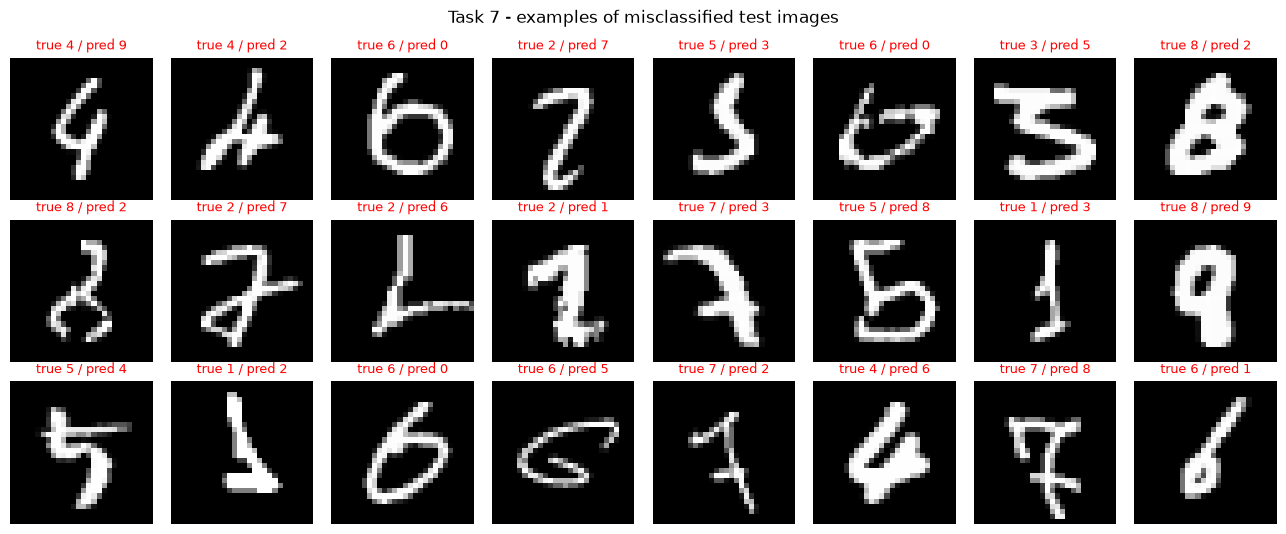

In [16]:
wrong = (test_preds != y_test).nonzero().squeeze(1)
print("Misclassified test images:", len(wrong))
fig, axes = plt.subplots(3, 8, figsize=(13, 5.4))
for ax, idx in zip(axes.flat, wrong[:24].tolist()):
    ax.imshow((X_test[idx, 0] * STD + MEAN).cpu(), cmap="gray"); ax.axis("off")
    ax.set_title(f"true {y_test[idx].item()} / pred {test_preds[idx].item()}", fontsize=9, color="red")
fig.suptitle("Task 7 - examples of misclassified test images")
plt.tight_layout(); save_fig("task07_misclassified.png"); plt.show()

**Result:**

**174** test images (1.74 %) are misclassified. Most of them are unusual or badly written digits (e.g. an open “4” read as 9, a “6” with a
closed loop read as 0, a very flat “2” read as 1) – several are hard even for a human.

---
# Task 8: Tuning the Parameters and Model Architecture
**Selection rule (no test-set tuning):** every configuration is trained on the 50k training split and compared on the
**validation** split – highest validation accuracy, ties broken by lowest validation loss. The test set is used once, at the end (8c).

## 8a) Learning rate × momentum
Model fixed to the Task 4 `SimpleNet` (784→512→10), batch 32, **8 epochs** per run, same seed for every run.

In [17]:
LRS        = [0.001, 0.01, 0.05, 0.1]
MOMENTA    = [0.0, 0.5, 0.9, 0.95]
TUNE_EPOCHS = 8

rows = []
for lr in LRS:
    for mom in MOMENTA:
        set_seed()
        m = SimpleNet()
        tl, _, _ = make_loaders()
        _, h = train(m, tl, epochs=TUNE_EPOCHS, lr=lr, momentum=mom, val_loader=val_loader,
                     verbose=False, name=f"grid lr={lr} m={mom}")
        best_ep = int(np.nanargmax(h["val_acc"])) if h["val_acc"] else 0
        rows.append({"lr": lr, "momentum": mom,
                     "final train loss": h["train_loss"][-1], "final val loss": h["val_loss"][-1],
                     "final val acc %": h["val_acc"][-1], "min val loss": np.nanmin(h["val_loss"]),
                     "max val acc %": np.nanmax(h["val_acc"]), "time s": h["time_s"]})
        print(f"lr={lr:<6} momentum={mom:<5} | val loss {h['val_loss'][-1]:.4f} | val acc {h['val_acc'][-1]:6.2f}% | {h['time_s']:.1f}s")

grid = pd.DataFrame(rows)
grid_sorted = grid.sort_values(["final val acc %", "final val loss"], ascending=[False, True]).reset_index(drop=True)
display(grid_sorted.round(4))
best_opt = grid_sorted.iloc[0]
BEST_LR, BEST_MOM = float(best_opt["lr"]), float(best_opt["momentum"])
print(f"Best on validation: lr={BEST_LR}, momentum={BEST_MOM} -> val acc {best_opt['final val acc %']:.2f}%, val loss {best_opt['final val loss']:.4f}")

lr=0.001  momentum=0.0   | val loss 0.3034 | val acc  91.17% | 9.3s
lr=0.001  momentum=0.5   | val loss 0.2439 | val acc  93.04% | 10.0s
lr=0.001  momentum=0.9   | val loss 0.1153 | val acc  96.51% | 10.0s
lr=0.001  momentum=0.95  | val loss 0.0879 | val acc  97.30% | 9.8s
lr=0.01   momentum=0.0   | val loss 0.1148 | val acc  96.54% | 9.9s
lr=0.01   momentum=0.5   | val loss 0.0869 | val acc  97.29% | 9.7s
lr=0.01   momentum=0.9   | val loss 0.0725 | val acc  97.87% | 9.8s
lr=0.01   momentum=0.95  | val loss 0.0846 | val acc  97.97% | 10.4s
lr=0.05   momentum=0.0   | val loss 0.0761 | val acc  97.71% | 9.5s
lr=0.05   momentum=0.5   | val loss 0.0726 | val acc  97.89% | 10.1s
lr=0.05   momentum=0.9   | val loss 0.3670 | val acc  95.76% | 9.8s
lr=0.05   momentum=0.95  | val loss 0.8350 | val acc  79.43% | 9.5s
lr=0.1    momentum=0.0   | val loss 0.0733 | val acc  97.85% | 10.0s
lr=0.1    momentum=0.5   | val loss 0.0795 | val acc  98.12% | 10.1s
lr=0.1    momentum=0.9   | val loss 0.9773

,lr,momentum,final train loss,final val loss,final val acc %,min val loss,max val acc %,time s
0,0.100,0.50,0.0062,0.0795,98.12,0.0793,98.12,10.1486
1,0.010,0.95,0.0044,0.0846,97.97,0.0846,97.97,10.3533
2,0.050,0.50,0.0054,0.0726,97.89,0.0690,97.97,10.1403
3,0.010,0.90,0.0050,0.0725,97.87,0.0693,97.99,9.7545
4,0.100,0.00,0.0050,0.0733,97.85,0.0697,97.87,9.9696
5,0.050,0.00,0.0166,0.0761,97.71,0.0717,97.72,9.5338
6,0.001,0.95,0.0492,0.0879,97.30,0.0879,97.30,9.7696
7,0.010,0.50,0.0489,0.0869,97.29,0.0869,97.29,9.6914
8,0.010,0.00,0.0890,0.1148,96.54,0.1148,96.54,9.8511
9,0.001,0.90,0.0891,0.1153,96.51,0.1153,96.51,9.9912


Best on validation: lr=0.1, momentum=0.5 -> val acc 98.12%, val loss 0.0795


saved -> screenshots\task08a_lr_momentum_heatmaps.png


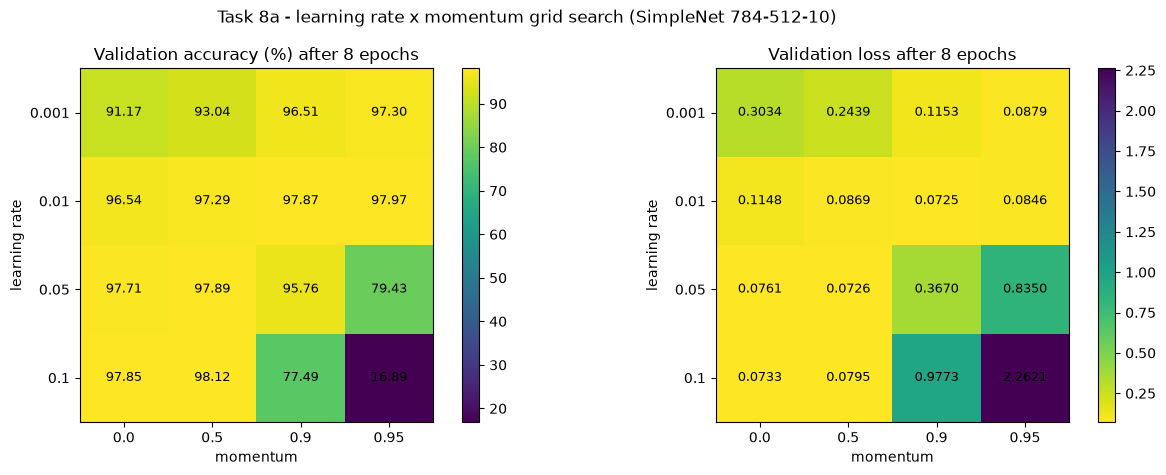

In [18]:
def heatmap(ax, table, title, fmt, cmap):
    im = ax.imshow(table.values, cmap=cmap)
    ax.set_xticks(range(table.shape[1])); ax.set_xticklabels(table.columns)
    ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index)
    ax.set_xlabel("momentum"); ax.set_ylabel("learning rate"); ax.set_title(title)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            v = table.values[i, j]
            ax.text(j, i, "nan" if not np.isfinite(v) else fmt.format(v), ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)

acc_tab  = grid.pivot(index="lr", columns="momentum", values="final val acc %")
loss_tab = grid.pivot(index="lr", columns="momentum", values="final val loss")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))
heatmap(a1, acc_tab,  f"Validation accuracy (%) after {TUNE_EPOCHS} epochs", "{:.2f}", "viridis")
heatmap(a2, loss_tab, f"Validation loss after {TUNE_EPOCHS} epochs",          "{:.4f}", "viridis_r")
fig.suptitle("Task 8a - learning rate x momentum grid search (SimpleNet 784-512-10)")
plt.tight_layout(); save_fig("task08a_lr_momentum_heatmaps.png"); plt.show()

**Result:**

| | learning rate | momentum | val accuracy | val loss |
|---|---|---|---|---|
| **Highest validation accuracy** | **0.1** | **0.5** | **98.12 %** | 0.0795 |
| **Lowest validation loss** | 0.01 | 0.9 | 97.87 % | **0.0725** |

* The best accuracy (lr 0.1, momentum 0.5) is selected for the next steps; lr 0.05 / momentum 0.5 is practically tied on loss (0.0726).
* A **too small** learning rate learns slowly: lr 0.001 without momentum only reaches 91.17 % in 8 epochs; momentum fixes much of this (97.30 % with 0.95).
* A **too large** step makes SGD unstable: lr 0.1 + momentum 0.95 collapses to 16.89 % and lr 0.05 + 0.95 to 79.43 %.
* Learning rate and momentum interact through the effective step ≈ lr / (1 − momentum): the best runs have an effective step of about 0.1–0.2
  (e.g. 0.1/0.5, 0.01/0.95, 0.01/0.9), while effective steps of 0.5 or more became unstable.

## 8b) Number of hidden layers × neurons per layer
Using the best learning rate / momentum from 8a, a general MLP with **1, 2 or 3 hidden layers** of
**64, 128, 256 or 512 neurons** each (ReLU after each hidden layer) is trained for 8 epochs.

In [19]:
class MLP(nn.Module):
    """Flatten -> [Linear -> (BatchNorm) -> ReLU -> (Dropout)] x n_layers -> Linear(10)."""
    def __init__(self, n_layers=1, width=512, batchnorm=False, dropout=0.0):
        super().__init__()
        layers, d_in = [], 28 * 28
        for _ in range(n_layers):
            layers.append(nn.Linear(d_in, width))
            if batchnorm: layers.append(nn.BatchNorm1d(width))
            layers.append(nn.ReLU())
            if dropout > 0: layers.append(nn.Dropout(dropout))
            d_in = width
        layers.append(nn.Linear(d_in, 10))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(torch.flatten(x, 1))

LAYERS, WIDTHS = [1, 2, 3], [64, 128, 256, 512]
arch_rows, arch_models = [], {}
for L in LAYERS:
    for W in WIDTHS:
        set_seed()
        m = MLP(L, W)
        tl, _, _ = make_loaders()
        _, h = train(m, tl, epochs=TUNE_EPOCHS, lr=BEST_LR, momentum=BEST_MOM, val_loader=val_loader,
                     verbose=False, name=f"arch {L}x{W}")
        arch_rows.append({"hidden layers": L, "neurons/layer": W, "params": count_params(m),
                          "final train loss": h["train_loss"][-1], "final val loss": h["val_loss"][-1],
                          "final val acc %": h["val_acc"][-1], "time s": h["time_s"]})
        print(f"{L} x {W:<4} | params {count_params(m):>9,} | val loss {h['val_loss'][-1]:.4f} | val acc {h['val_acc'][-1]:6.2f}%")

arch = pd.DataFrame(arch_rows)
arch_sorted = arch.sort_values(["final val acc %", "final val loss"], ascending=[False, True]).reset_index(drop=True)
display(arch_sorted.round(4))
best_arch = arch_sorted.iloc[0]
BEST_L, BEST_W = int(best_arch["hidden layers"]), int(best_arch["neurons/layer"])
print(f"Best architecture on validation: {BEST_L} hidden layer(s) x {BEST_W} neurons "
      f"-> val acc {best_arch['final val acc %']:.2f}%, val loss {best_arch['final val loss']:.4f}")

1 x 64   | params    50,890 | val loss 0.1538 | val acc  96.73%
1 x 128  | params   101,770 | val loss 0.1133 | val acc  97.45%
1 x 256  | params   203,530 | val loss 0.1052 | val acc  97.65%
1 x 512  | params   407,050 | val loss 0.0795 | val acc  98.12%
2 x 64   | params    55,050 | val loss 0.1399 | val acc  97.01%
2 x 128  | params   118,282 | val loss 0.1321 | val acc  97.11%
2 x 256  | params   269,322 | val loss 0.1168 | val acc  97.27%
2 x 512  | params   669,706 | val loss 0.0977 | val acc  97.82%
3 x 64   | params    59,210 | val loss 0.1222 | val acc  96.88%
3 x 128  | params   134,794 | val loss 0.1039 | val acc  97.60%
3 x 256  | params   335,114 | val loss 0.1138 | val acc  97.57%
3 x 512  | params   932,362 | val loss 0.1050 | val acc  97.61%


,hidden layers,neurons/layer,params,final train loss,final val loss,final val acc %,time s
0,1,512,407050,0.0062,0.0795,98.12,10.0013
1,2,512,669706,0.0112,0.0977,97.82,11.2392
2,1,256,203530,0.0077,0.1052,97.65,10.1461
3,3,512,932362,0.0194,0.1050,97.61,12.9857
4,3,128,134794,0.0335,0.1039,97.60,12.9138
5,3,256,335114,0.0205,0.1138,97.57,13.4154
6,1,128,101770,0.0233,0.1133,97.45,10.5026
7,2,256,269322,0.0171,0.1168,97.27,11.9790
8,2,128,118282,0.0280,0.1321,97.11,11.6026
9,2,64,55050,0.0510,0.1399,97.01,11.8650


Best architecture on validation: 1 hidden layer(s) x 512 neurons -> val acc 98.12%, val loss 0.0795


saved -> screenshots\task08b_architecture.png


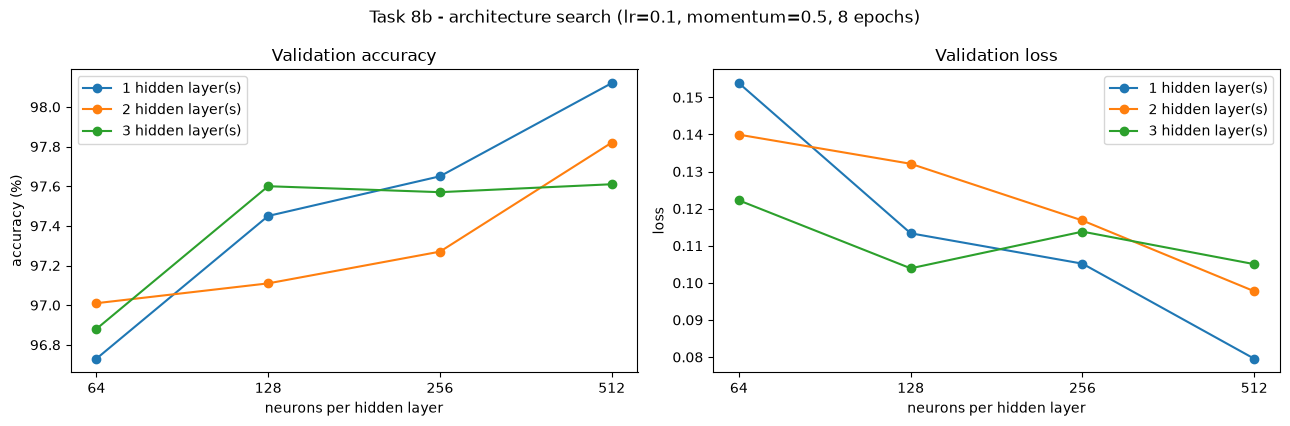

In [20]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3))
for L in LAYERS:
    d = arch[arch["hidden layers"] == L]
    a1.plot(d["neurons/layer"], d["final val acc %"], "o-", label=f"{L} hidden layer(s)")
    a2.plot(d["neurons/layer"], d["final val loss"], "o-", label=f"{L} hidden layer(s)")
for a, t, yl in [(a1, "Validation accuracy", "accuracy (%)"), (a2, "Validation loss", "loss")]:
    a.set_xscale("log", base=2); a.set_xticks(WIDTHS); a.set_xticklabels(WIDTHS)
    a.set_xlabel("neurons per hidden layer"); a.set_ylabel(yl); a.set_title(t); a.legend()
fig.suptitle(f"Task 8b - architecture search (lr={BEST_LR}, momentum={BEST_MOM}, {TUNE_EPOCHS} epochs)")
plt.tight_layout(); save_fig("task08b_architecture.png"); plt.show()

**Result:**

| | hidden layers | neurons | params | val accuracy | val loss |
|---|---|---|---|---|---|
| **Best (highest accuracy and lowest loss)** | **1** | **512** | 407,050 | **98.12 %** | **0.0795** |
| 2nd | 2 | 512 | 669,706 | 97.82 % | 0.0977 |

* **More neurons help** at every depth (1 layer: 96.73 % with 64 → 98.12 % with 512).
* **More layers did not help here:** 3×512 reaches 97.61 % although it has 2.3× the parameters. With only 8 epochs and a learning rate tuned
  for the one-layer network, deeper MLPs are harder to optimise, and MNIST is simple enough for one wide hidden layer.
* The 1×512 result is identical to Task 8a (same seed), confirming the runs are reproducible.

## 8c) Final model – selected on validation, tested once
The best architecture (8b) is trained with the best learning rate / momentum (8a) for 20 epochs.
The weights of the epoch with the **highest validation accuracy** are kept; only that model is evaluated on the test set.

In [21]:
FINAL_EPOCHS = 20

def train_with_checkpoint(net, epochs, lr, momentum, name):
    """Same SGD + CrossEntropy training as train(), but keeps the weights of the best-validation epoch."""
    net.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum)
    tl, _, _ = make_loaders()
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_key, best_state, best_epoch = None, None, None
    t0 = time.perf_counter()
    for ep in range(epochs):
        net.train(); ls = []
        for xb, yb in tl:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(net(xb), yb); loss.backward(); optimizer.step()
            ls.append(loss.detach())
        tr_loss = torch.stack(ls).mean().item()
        v_loss, v_acc = evaluate(net, val_loader)
        hist["train_loss"].append(tr_loss); hist["val_loss"].append(v_loss); hist["val_acc"].append(v_acc)
        key = (v_acc, -v_loss)
        if best_key is None or key > best_key:
            best_key, best_state, best_epoch = key, copy.deepcopy(net.state_dict()), ep + 1
        print(f"epoch {ep+1:>2}/{epochs} | train loss {tr_loss:.4f} | val loss {v_loss:.4f} | val acc {v_acc:6.2f}%")
    torch.cuda.synchronize()
    hist["time_s"] = time.perf_counter() - t0
    TIMINGS.append({"model": name, "device": str(DEVICE), "epochs": epochs, "seconds": hist["time_s"]})
    net.load_state_dict(best_state)
    hist["best_epoch"] = best_epoch
    return hist

set_seed()
final_net = MLP(BEST_L, BEST_W)
final_hist = train_with_checkpoint(final_net, FINAL_EPOCHS, BEST_LR, BEST_MOM, f"Tuned MLP {BEST_L}x{BEST_W} (Task 8c)")
be = final_hist["best_epoch"]
print(f"\nSelected epoch {be}: val loss {final_hist['val_loss'][be-1]:.4f}, val acc {final_hist['val_acc'][be-1]:.2f}% "
      f"| training time {final_hist['time_s']:.1f}s")

epoch  1/20 | train loss 0.1964 | val loss 0.1061 | val acc  96.73%
epoch  2/20 | train loss 0.0816 | val loss 0.1099 | val acc  96.63%
epoch  3/20 | train loss 0.0530 | val loss 0.0982 | val acc  97.20%
epoch  4/20 | train loss 0.0329 | val loss 0.0793 | val acc  97.58%
epoch  5/20 | train loss 0.0219 | val loss 0.0924 | val acc  97.62%
epoch  6/20 | train loss 0.0142 | val loss 0.0808 | val acc  97.97%
epoch  7/20 | train loss 0.0075 | val loss 0.0801 | val acc  98.06%
epoch  8/20 | train loss 0.0062 | val loss 0.0795 | val acc  98.12%
epoch  9/20 | train loss 0.0033 | val loss 0.0794 | val acc  98.02%
epoch 10/20 | train loss 0.0014 | val loss 0.0773 | val acc  98.19%
epoch 11/20 | train loss 0.0004 | val loss 0.0770 | val acc  98.23%
epoch 12/20 | train loss 0.0003 | val loss 0.0777 | val acc  98.22%
epoch 13/20 | train loss 0.0002 | val loss 0.0787 | val acc  98.22%
epoch 14/20 | train loss 0.0002 | val loss 0.0788 | val acc  98.23%
epoch 15/20 | train loss 0.0002 | val loss 0.079

,model,lr,momentum,epochs,params,val loss,val acc %,test loss,test acc %
0,Task 6 baseline SimpleNet 784-512-10,0.01,0.9,10,407050,0.0727,97.92,0.0603,98.26
1,8a best lr/momentum (SimpleNet),0.10,0.5,8,407050,0.0795,98.12,NaN,NaN
2,8b best architecture 1x512,0.10,0.5,8,407050,0.0795,98.12,NaN,NaN
3,8c FINAL tuned MLP 1x512 (epoch 15),0.10,0.5,20,407050,0.0793,98.26,0.0682,98.55


,search,criterion,setting,val acc %,val loss
0,8a lr x momentum,highest val accuracy,"lr=0.1, momentum=0.5",98.12,0.0795
1,8a lr x momentum,lowest val loss,"lr=0.01, momentum=0.9",97.87,0.0725
2,8b architecture,highest val accuracy,1 x 512,98.12,0.0795
3,8b architecture,lowest val loss,1 x 512,98.12,0.0795


FINAL tuned model -> TEST accuracy 98.55% | TEST loss 0.0682 (selected on validation: val acc 98.26%, val loss 0.0793)
Task 6 baseline   -> TEST accuracy 98.26% | TEST loss 0.0603
saved -> screenshots\task08c_final_model.png


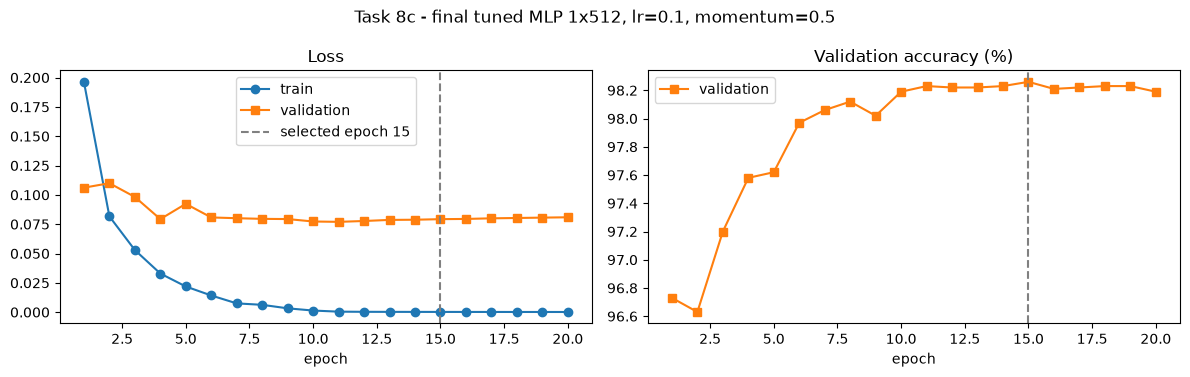

In [22]:
# ---- the ONLY test-set evaluation of the tuned model ----
final_val_loss, final_val_acc = evaluate(final_net, val_loader)
final_test_loss, final_test_acc = evaluate(final_net, test_loader)
base_val_loss, base_val_acc = hist["val_loss"][-1], hist["val_acc"][-1]

summary = pd.DataFrame([
    {"model": "Task 6 baseline SimpleNet 784-512-10", "lr": LR, "momentum": MOMENTUM, "epochs": EPOCHS,
     "params": count_params(net), "val loss": base_val_loss, "val acc %": base_val_acc,
     "test loss": test_loss, "test acc %": test_acc},
    {"model": "8a best lr/momentum (SimpleNet)", "lr": BEST_LR, "momentum": BEST_MOM, "epochs": TUNE_EPOCHS,
     "params": count_params(SimpleNet()), "val loss": best_opt["final val loss"], "val acc %": best_opt["final val acc %"],
     "test loss": np.nan, "test acc %": np.nan},
    {"model": f"8b best architecture {BEST_L}x{BEST_W}", "lr": BEST_LR, "momentum": BEST_MOM, "epochs": TUNE_EPOCHS,
     "params": int(best_arch["params"]), "val loss": best_arch["final val loss"], "val acc %": best_arch["final val acc %"],
     "test loss": np.nan, "test acc %": np.nan},
    {"model": f"8c FINAL tuned MLP {BEST_L}x{BEST_W} (epoch {be})", "lr": BEST_LR, "momentum": BEST_MOM, "epochs": FINAL_EPOCHS,
     "params": count_params(final_net), "val loss": final_val_loss, "val acc %": final_val_acc,
     "test loss": final_test_loss, "test acc %": final_test_acc},
])
display(summary.round(4))

# best results of the tuning (validation) - highest accuracy and lowest loss
low_opt  = grid.sort_values(["final val loss", "final val acc %"], ascending=[True, False]).iloc[0]
low_arch = arch.sort_values(["final val loss", "final val acc %"], ascending=[True, False]).iloc[0]
best_tab = pd.DataFrame([
    {"search": "8a lr x momentum", "criterion": "highest val accuracy", "setting": f"lr={best_opt['lr']}, momentum={best_opt['momentum']}",
     "val acc %": best_opt["final val acc %"], "val loss": best_opt["final val loss"]},
    {"search": "8a lr x momentum", "criterion": "lowest val loss", "setting": f"lr={low_opt['lr']}, momentum={low_opt['momentum']}",
     "val acc %": low_opt["final val acc %"], "val loss": low_opt["final val loss"]},
    {"search": "8b architecture", "criterion": "highest val accuracy", "setting": f"{int(best_arch['hidden layers'])} x {int(best_arch['neurons/layer'])}",
     "val acc %": best_arch["final val acc %"], "val loss": best_arch["final val loss"]},
    {"search": "8b architecture", "criterion": "lowest val loss", "setting": f"{int(low_arch['hidden layers'])} x {int(low_arch['neurons/layer'])}",
     "val acc %": low_arch["final val acc %"], "val loss": low_arch["final val loss"]},
])
display(best_tab.round(4))
print(f"FINAL tuned model -> TEST accuracy {final_test_acc:.2f}% | TEST loss {final_test_loss:.4f} "
      f"(selected on validation: val acc {final_val_acc:.2f}%, val loss {final_val_loss:.4f})")
print(f"Task 6 baseline   -> TEST accuracy {test_acc:.2f}% | TEST loss {test_loss:.4f}")

ep = np.arange(1, FINAL_EPOCHS + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(ep, final_hist["train_loss"], "o-", label="train"); a1.plot(ep, final_hist["val_loss"], "s-", label="validation")
a1.axvline(be, color="gray", ls="--", label=f"selected epoch {be}"); a1.set_title("Loss"); a1.set_xlabel("epoch"); a1.legend()
a2.plot(ep, final_hist["val_acc"], "s-", color="tab:orange", label="validation")
a2.axvline(be, color="gray", ls="--"); a2.set_title("Validation accuracy (%)"); a2.set_xlabel("epoch"); a2.legend()
fig.suptitle(f"Task 8c - final tuned MLP {BEST_L}x{BEST_W}, lr={BEST_LR}, momentum={BEST_MOM}")
plt.tight_layout(); save_fig("task08c_final_model.png"); plt.show()

**Result:**

* **Final model:** 1 hidden layer × 512 neurons, lr 0.1, momentum 0.5, trained 20 epochs; epoch **15** had the highest validation
  accuracy (**98.26 %**, val loss 0.0793) and its weights were kept.
* **Test (evaluated once): accuracy 98.55 %, loss 0.0682** – 145 errors vs 174 for the Task 6 baseline (29 fewer mistakes).
* **Best results:** highest accuracy → tuned model (98.55 % test / 98.26 % val); lowest validation loss during tuning → lr 0.01, momentum 0.9 (0.0725).
* Note: the baseline has a slightly lower *test loss* (0.0603) despite lower accuracy. The tuned model drives the training loss to ≈0.0001 and
  becomes very confident, so its few wrong answers cost more cross-entropy – accuracy and loss do not always agree.

---
# Task 9: Save the Source Code
The source code is this notebook (`Assigment-1 DL.ipynb`) plus a plain-Python export (`Assigment-1 DL.py`), together with
`README.md`, `requirements.txt`, `.gitignore` (excludes `.venv/`, `data/`, `checkpoints/`, `__pycache__/`) and the
`screenshots/` folder. The best model's weights are saved below to a small file and pushed to GitHub:
[https://github.com/KhalidExe/ARTI502-Assignment1](https://github.com/KhalidExe/ARTI502-Assignment1)

In [23]:
MODEL_PATH = os.path.join("models", "best_mlp.pt")
torch.save({"state_dict": final_net.state_dict(),
            "config": {"hidden_layers": BEST_L, "neurons": BEST_W, "lr": BEST_LR, "momentum": BEST_MOM,
                       "best_epoch": be, "val_acc": final_val_acc, "test_acc": final_test_acc}}, MODEL_PATH)
print(f"saved {MODEL_PATH}  ({os.path.getsize(MODEL_PATH) / 1024:.1f} KB)")

# reload check
ck = torch.load(MODEL_PATH, map_location=DEVICE)
reloaded = MLP(ck["config"]["hidden_layers"], ck["config"]["neurons"]).to(DEVICE)
reloaded.load_state_dict(ck["state_dict"])
print("reloaded model test accuracy: %.2f%%" % evaluate(reloaded, test_loader)[1])

saved models\best_mlp.pt  (1592.7 KB)
reloaded model test accuracy: 98.55%


**Result:**

The best model is saved to `models/best_mlp.pt` (**1592.7 KB**) together with its configuration. Reloading the file gives the same
**98.55 %** test accuracy, so the saved weights are valid. The source code is on GitHub.

---
# Beyond Requirements (extra work – not part of the graded baseline)
Everything above follows the assignment exactly. The following experiments are **additional**.

## B1) MLP: effect of Dropout and BatchNorm
Architecture 2 hidden layers × 512, SGD (lr 0.01, momentum 0.9), batch 32, 15 epochs. Test accuracy is reported only, never used for selection.

plain                    val acc  98.09% | test acc  98.51%
dropout 0.2              val acc  98.06% | test acc  98.22%
batchnorm                val acc  98.27% | test acc  98.22%
batchnorm + dropout 0.2  val acc  98.08% | test acc  98.39%


,variant,params,train loss,val loss,val acc %,test acc %,train-val acc gap,time s
0,plain,669706,0.0002,0.0897,98.09,98.51,1.910,21.7463
1,dropout 0.2,669706,0.0137,0.0835,98.06,98.22,1.508,25.0312
2,batchnorm,671754,0.0059,0.0636,98.27,98.22,1.544,30.2792
3,batchnorm + dropout 0.2,671754,0.0256,0.0686,98.08,98.39,1.026,33.1676


saved -> screenshots\beyond_b1_dropout_batchnorm.png


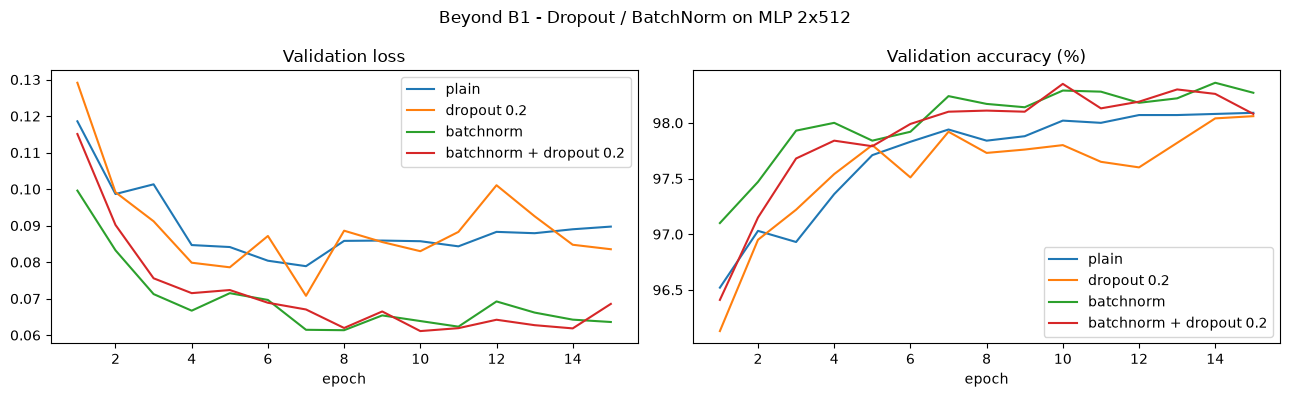

In [24]:
RESULTS = []   # rows for the final comparison table
RESULTS.append({"model": "SimpleNet baseline (Task 6)", "params": count_params(net), "epochs": EPOCHS,
                "time s": hist["time_s"], "val acc %": hist["val_acc"][-1], "test acc %": test_acc})
RESULTS.append({"model": f"Tuned MLP {BEST_L}x{BEST_W} (Task 8c)", "params": count_params(final_net), "epochs": FINAL_EPOCHS,
                "time s": final_hist["time_s"], "val acc %": final_val_acc, "test acc %": final_test_acc})

variants = {"plain": dict(), "dropout 0.2": dict(dropout=0.2),
            "batchnorm": dict(batchnorm=True), "batchnorm + dropout 0.2": dict(batchnorm=True, dropout=0.2)}
reg_rows, reg_hist = [], {}
for vname, kw in variants.items():
    set_seed()
    m = MLP(2, 512, **kw)
    tl, _, _ = make_loaders()
    _, h = train(m, tl, epochs=15, lr=0.01, momentum=0.9, val_loader=val_loader, verbose=False, name=f"MLP 2x512 {vname}")
    t_loss, t_acc = evaluate(m, test_loader)
    reg_hist[vname] = h
    reg_rows.append({"variant": vname, "params": count_params(m), "train loss": h["train_loss"][-1],
                     "val loss": h["val_loss"][-1], "val acc %": h["val_acc"][-1], "test acc %": t_acc,
                     "train-val acc gap": h["train_acc"][-1] - h["val_acc"][-1], "time s": h["time_s"]})
    RESULTS.append({"model": f"MLP 2x512 {vname}", "params": count_params(m), "epochs": 15,
                    "time s": h["time_s"], "val acc %": h["val_acc"][-1], "test acc %": t_acc})
    print(f"{vname:<24} val acc {h['val_acc'][-1]:6.2f}% | test acc {t_acc:6.2f}%")
display(pd.DataFrame(reg_rows).round(4))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
for vname, h in reg_hist.items():
    e = np.arange(1, len(h["val_loss"]) + 1)
    a1.plot(e, h["val_loss"], label=vname); a2.plot(e, h["val_acc"], label=vname)
a1.set_title("Validation loss"); a2.set_title("Validation accuracy (%)")
for a in (a1, a2): a.set_xlabel("epoch"); a.legend()
fig.suptitle("Beyond B1 - Dropout / BatchNorm on MLP 2x512")
plt.tight_layout(); save_fig("beyond_b1_dropout_batchnorm.png"); plt.show()

**Result:**

* All four variants reach ≈98.1–98.3 % validation accuracy. **BatchNorm** gives the lowest validation loss (0.0636 vs 0.0897 plain) and the highest val accuracy (98.27 %).
* **Dropout reduces overfitting:** the train–validation accuracy gap shrinks from 1.91 (plain) to 1.51 (dropout) and 1.03 (BatchNorm + dropout), and the val loss improves (0.0897 → 0.0835).
* On the test set the plain MLP happened to score best (98.51 %); differences of ≈0.3 % (≈30 images) are small for a network of this size.
  BatchNorm costs ≈40–50 % more time (30.3 s / 33.2 s vs 21.7 s).

## B2) CNN with BatchNorm, Dropout and light data augmentation + LR scheduler & early stopping
* 4 conv layers (32-32-64-64, 3×3) with BatchNorm + ReLU, 2 max-pool stages, Dropout, FC 128 → 10.
* Augmentation (training only, on the GPU): random rotation ±10°, shift ±2 px, scale 0.9–1.1.
* Optimizer Adam (lr 1e-3), **ReduceLROnPlateau** on validation loss (factor 0.3, patience 2) and
  **early stopping** (patience 5) – the weights with the lowest validation loss are restored.

saved -> screenshots\beyond_b2_augmentation.png


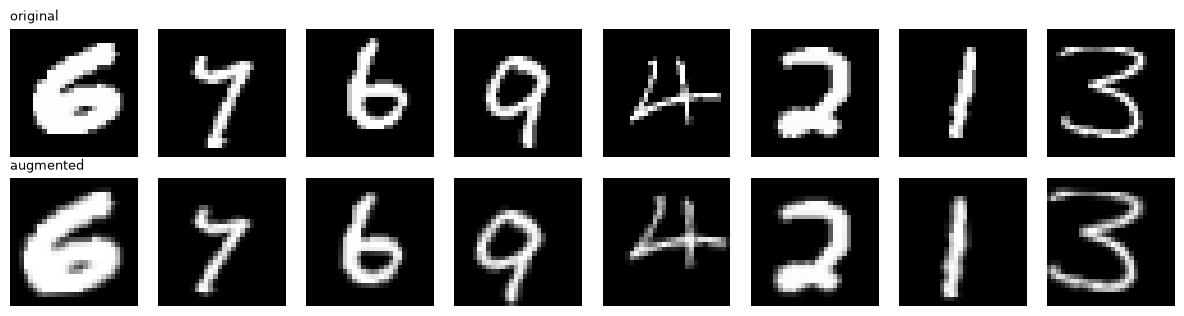

CNN parameters: 468,138
epoch  1 | lr 1.0e-03 | train loss 0.2710 | val loss 0.0429 | val acc  98.66% *
epoch  2 | lr 1.0e-03 | train loss 0.0850 | val loss 0.0268 | val acc  99.22% *
epoch  3 | lr 1.0e-03 | train loss 0.0666 | val loss 0.0254 | val acc  99.27% *
epoch  4 | lr 1.0e-03 | train loss 0.0582 | val loss 0.0244 | val acc  99.18% *
epoch  5 | lr 1.0e-03 | train loss 0.0538 | val loss 0.0231 | val acc  99.29% *
epoch  6 | lr 1.0e-03 | train loss 0.0454 | val loss 0.0207 | val acc  99.33% *
epoch  7 | lr 1.0e-03 | train loss 0.0439 | val loss 0.0160 | val acc  99.51% *
epoch  8 | lr 1.0e-03 | train loss 0.0402 | val loss 0.0181 | val acc  99.44% 
epoch  9 | lr 1.0e-03 | train loss 0.0371 | val loss 0.0202 | val acc  99.37% 
epoch 10 | lr 1.0e-03 | train loss 0.0386 | val loss 0.0177 | val acc  99.35% 
epoch 11 | lr 3.0e-04 | train loss 0.0290 | val loss 0.0121 | val acc  99.61% *
epoch 12 | lr 3.0e-04 | train loss 0.0274 | val loss 0.0127 | val acc  99.56% 
epoch 13 | lr 3.0e-0

In [25]:
class CNN(nn.Module):
    def __init__(self, p_drop=0.25):
        super().__init__()
        def block(cin, cout):
            return [nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True)]
        self.features = nn.Sequential(*block(1, 32), *block(32, 32), nn.MaxPool2d(2), nn.Dropout(p_drop),
                                      *block(32, 64), *block(64, 64), nn.MaxPool2d(2), nn.Dropout(p_drop))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 7 * 7, 128, bias=False), nn.BatchNorm1d(128),
                                        nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(128, 10))
    def forward(self, x):
        return self.classifier(self.features(x))

def augment(x, max_rot=10, max_shift_px=2, scale=(0.9, 1.1)):
    """Random affine (rotation / shift / scale) on a normalised GPU batch."""
    n = x.size(0)
    ang = (torch.rand(n, device=x.device) * 2 - 1) * math.radians(max_rot)
    s = torch.empty(n, device=x.device).uniform_(*scale)
    t = (torch.rand(n, 2, device=x.device) * 2 - 1) * (2 * max_shift_px / 28)
    cos, sin = torch.cos(ang) / s, torch.sin(ang) / s
    theta = torch.stack([torch.stack([cos, -sin, t[:, 0]], 1), torch.stack([sin, cos, t[:, 1]], 1)], 1)
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    raw = x * STD + MEAN                                   # background -> 0 before padding with zeros
    return (F.grid_sample(raw, grid, align_corners=False, padding_mode="zeros") - MEAN) / STD

def train_advanced(net, epochs=40, lr=1e-3, batch_size=128, patience=5, use_aug=True, name="model"):
    net.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=2)
    tl = GPUBatchLoader(X_train, y_train, batch_size, True, SEED)
    h = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}
    best_loss, best_state, best_epoch, bad = float("inf"), None, 0, 0
    t0 = time.perf_counter()
    for ep in range(epochs):
        net.train(); ls = []
        for xb, yb in tl:
            if use_aug: xb = augment(xb)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(net(xb), yb); loss.backward(); optimizer.step()
            ls.append(loss.detach())
        tr_loss = torch.stack(ls).mean().item()
        v_loss, v_acc = evaluate(net, val_loader)
        h["train_loss"].append(tr_loss); h["val_loss"].append(v_loss); h["val_acc"].append(v_acc)
        h["lr"].append(optimizer.param_groups[0]["lr"])
        scheduler.step(v_loss)
        flag = ""
        if v_loss < best_loss:
            best_loss, best_state, best_epoch, bad = v_loss, copy.deepcopy(net.state_dict()), ep + 1, 0; flag = "*"
        else:
            bad += 1
        print(f"epoch {ep+1:>2} | lr {h['lr'][-1]:.1e} | train loss {tr_loss:.4f} | val loss {v_loss:.4f} | val acc {v_acc:6.2f}% {flag}")
        if bad >= patience:
            print(f"early stopping: no val-loss improvement for {patience} epochs"); break
    torch.cuda.synchronize()
    h["time_s"] = time.perf_counter() - t0; h["best_epoch"] = best_epoch
    TIMINGS.append({"model": name, "device": str(DEVICE), "epochs": len(h["val_loss"]), "seconds": h["time_s"]})
    net.load_state_dict(best_state)
    return h

# preview of the augmentation
set_seed()
aug = augment(X_train[:8])
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow((X_train[i, 0] * STD + MEAN).cpu(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow((aug[i, 0] * STD + MEAN).cpu(), cmap="gray");     axes[1, i].axis("off")
axes[0, 0].set_title("original", fontsize=9, loc="left"); axes[1, 0].set_title("augmented", fontsize=9, loc="left")
plt.tight_layout(); save_fig("beyond_b2_augmentation.png"); plt.show()

set_seed()
cnn = CNN()
print(f"CNN parameters: {count_params(cnn):,}")
cnn_hist = train_advanced(cnn, epochs=40, name="CNN + BN + Dropout + aug")
cnn_val_loss, cnn_val_acc = evaluate(cnn, val_loader)
cnn_test_loss, cnn_test_acc, cnn_preds = evaluate(cnn, test_loader, return_preds=True)
print(f"\nRestored epoch {cnn_hist['best_epoch']} | val acc {cnn_val_acc:.2f}% | TEST loss {cnn_test_loss:.4f} "
      f"| TEST acc {cnn_test_acc:.2f}% ({(cnn_preds != y_test).sum().item()} errors) | time {cnn_hist['time_s']:.1f}s")
RESULTS.append({"model": "CNN + BN + Dropout + augmentation", "params": count_params(cnn), "epochs": len(cnn_hist["val_loss"]),
                "time s": cnn_hist["time_s"], "val acc %": cnn_val_acc, "test acc %": cnn_test_acc})

saved -> screenshots\beyond_b2_cnn_training.png


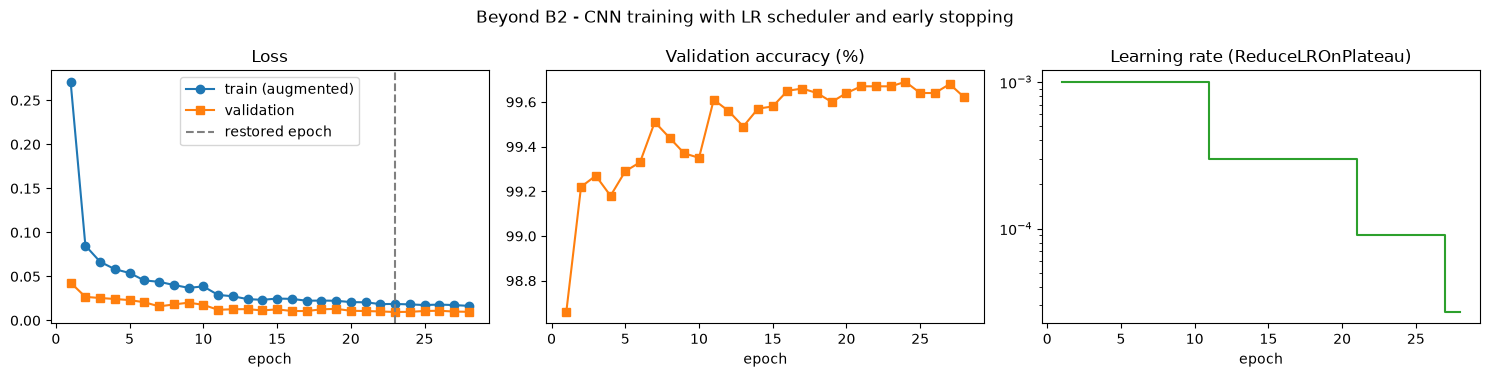

saved -> screenshots\beyond_b2_cnn_errors.png


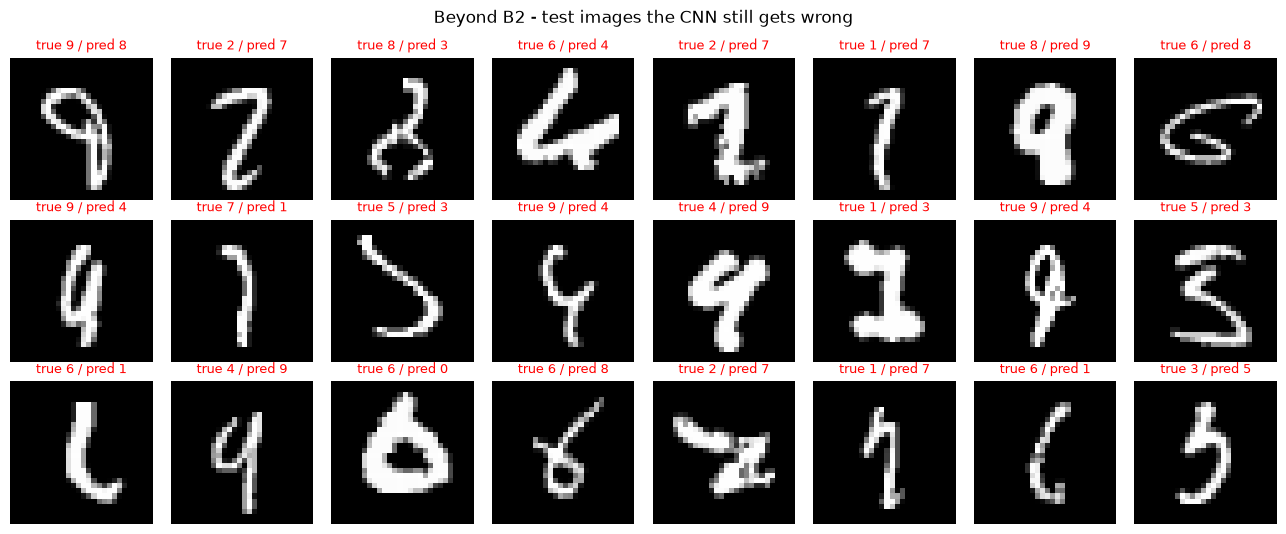

In [26]:
e = np.arange(1, len(cnn_hist["val_loss"]) + 1)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 3.8))
a1.plot(e, cnn_hist["train_loss"], "o-", label="train (augmented)"); a1.plot(e, cnn_hist["val_loss"], "s-", label="validation")
a1.axvline(cnn_hist["best_epoch"], color="gray", ls="--", label="restored epoch"); a1.set_title("Loss"); a1.legend()
a2.plot(e, cnn_hist["val_acc"], "s-", color="tab:orange"); a2.set_title("Validation accuracy (%)")
a3.step(e, cnn_hist["lr"], where="post", color="tab:green"); a3.set_yscale("log"); a3.set_title("Learning rate (ReduceLROnPlateau)")
for a in (a1, a2, a3): a.set_xlabel("epoch")
fig.suptitle("Beyond B2 - CNN training with LR scheduler and early stopping")
plt.tight_layout(); save_fig("beyond_b2_cnn_training.png"); plt.show()

wrong = (cnn_preds != y_test).nonzero().squeeze(1)
fig, axes = plt.subplots(3, 8, figsize=(13, 5.4))
for ax in axes.flat: ax.axis("off")
for ax, idx in zip(axes.flat, wrong[:24].tolist()):
    ax.imshow((X_test[idx, 0] * STD + MEAN).cpu(), cmap="gray")
    ax.set_title(f"true {y_test[idx].item()} / pred {cnn_preds[idx].item()}", fontsize=9, color="red")
fig.suptitle("Beyond B2 - test images the CNN still gets wrong")
plt.tight_layout(); save_fig("beyond_b2_cnn_errors.png"); plt.show()

**Result:**

* The CNN (468,138 parameters) stopped early after **epoch 28** (no val-loss improvement for 5 epochs). `ReduceLROnPlateau` lowered the
  learning rate 1e-3 → 3e-4 (epoch 11) → 9e-5 (epoch 21) → 2.7e-5 (epoch 27); each drop improved the validation loss.
* The weights of epoch 23 (lowest val loss 0.0096) were restored: **val accuracy 99.67 %, test loss 0.0087, test accuracy 99.65 %** – only
  **35 errors** out of 10,000, above the ≈99.5 % target (the best MLP had 145 errors).
* Training loss is higher than validation loss because training uses augmented images and dropout.
* Convolutions use the 2-D structure of the image (local strokes, shift invariance) instead of treating the 784 pixels independently.
  The remaining errors are mostly ambiguous digits (e.g. a “6” that looks like “0”, a “4” that looks like “9”).

## B3) CPU vs GPU training time
One epoch of the Task 4 `SimpleNet` (batch 32) and one epoch of the CNN (batch 128, no augmentation) on each device,
with identical data and code (the CPU run uses copies of the tensors in RAM).

CPU threads used by PyTorch: 16
SimpleNet 784-512-10   CPU    1.01s | GPU   1.41s | x0.7
CNN                    CPU   15.46s | GPU   1.31s | x11.8


,model,batch,CPU s/epoch,GPU s/epoch,speed-up (x)
0,SimpleNet 784-512-10,32,1.01,1.41,0.71
1,CNN,128,15.46,1.31,11.80


saved -> screenshots\beyond_b3_cpu_vs_gpu.png


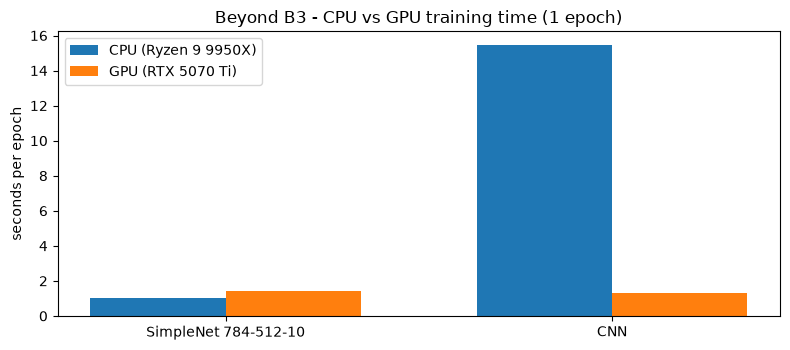

In [27]:
def time_one_epoch(model_fn, device, batch_size):
    set_seed()
    m = model_fn().to(device)
    opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    X, y = X_train.to(device), y_train.to(device)
    loader = GPUBatchLoader(X, y, batch_size, True, SEED)
    m.train()
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for xb, yb in loader:
        opt.zero_grad(set_to_none=True); loss = crit(m(xb), yb); loss.backward(); opt.step()
    if device.type == "cuda": torch.cuda.synchronize()
    return time.perf_counter() - t0

CPU = torch.device("cpu")
print("CPU threads used by PyTorch:", torch.get_num_threads())
speed = []
for label, fn, bs in [("SimpleNet 784-512-10", SimpleNet, 32), ("CNN", CNN, 128)]:
    t_cpu = time_one_epoch(fn, CPU, bs)
    t_gpu = time_one_epoch(fn, DEVICE, bs)
    speed.append({"model": label, "batch": bs, "CPU s/epoch": t_cpu, "GPU s/epoch": t_gpu, "speed-up (x)": t_cpu / t_gpu})
    TIMINGS.append({"model": f"{label} 1 epoch", "device": "cpu", "epochs": 1, "seconds": t_cpu})
    TIMINGS.append({"model": f"{label} 1 epoch", "device": "cuda", "epochs": 1, "seconds": t_gpu})
    print(f"{label:<22} CPU {t_cpu:7.2f}s | GPU {t_gpu:6.2f}s | x{t_cpu / t_gpu:.1f}")
speed_df = pd.DataFrame(speed); display(speed_df.round(2))

fig, ax = plt.subplots(figsize=(8, 3.6))
xx = np.arange(len(speed_df)); w = 0.35
ax.bar(xx - w/2, speed_df["CPU s/epoch"], w, label="CPU (Ryzen 9 9950X)")
ax.bar(xx + w/2, speed_df["GPU s/epoch"], w, label="GPU (RTX 5070 Ti)")
ax.set_xticks(xx); ax.set_xticklabels(speed_df["model"]); ax.set_ylabel("seconds per epoch"); ax.legend()
ax.set_title("Beyond B3 - CPU vs GPU training time (1 epoch)")
plt.tight_layout(); save_fig("beyond_b3_cpu_vs_gpu.png"); plt.show()

**Result:**

* **CNN: CPU 15.46 s vs GPU 1.31 s per epoch → the GPU is 11.8× faster.**
* **SimpleNet (batch 32): CPU 1.01 s vs GPU 1.41 s → the GPU is slower (0.71×).** The model is tiny (0.4 M parameters) and each batch of 32
  is too small to keep the GPU busy, so the 1,563 steps per epoch are dominated by kernel-launch and Python overhead, while the 16-core CPU
  handles such small matrix products very efficiently. The GPU only pays off when there is enough work per batch (convolutions, bigger models/batches).

## B4) Final comparison of all models
Validation accuracy is the selection metric; test accuracy is only reported.

,model,params,epochs,time s,val acc %,test acc %,test errors
0,SimpleNet baseline (Task 6),407050,10,13.273,97.92,98.26,174
1,Tuned MLP 1x512 (Task 8c),407050,20,22.581,98.26,98.55,145
2,MLP 2x512 plain,669706,15,21.746,98.09,98.51,149
3,MLP 2x512 dropout 0.2,669706,15,25.031,98.06,98.22,178
4,MLP 2x512 batchnorm,671754,15,30.279,98.27,98.22,178
5,MLP 2x512 batchnorm + dropout 0.2,671754,15,33.168,98.08,98.39,161
6,CNN + BN + Dropout + augmentation,468138,28,50.211,99.67,99.65,35


saved -> screenshots\beyond_b4_model_comparison.png


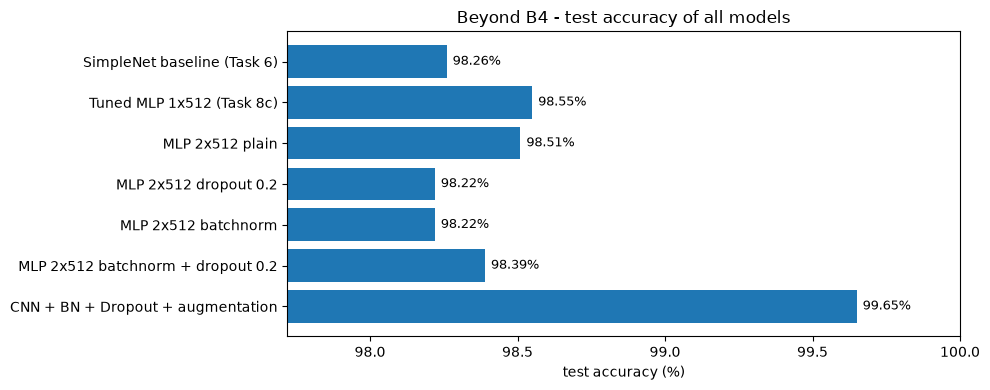

In [28]:
comp = pd.DataFrame(RESULTS)
comp["test errors"] = ((100 - comp["test acc %"]) / 100 * len(y_test)).round().astype(int)
display(comp.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(comp["model"], comp["test acc %"], color="tab:blue")
for i, v in enumerate(comp["test acc %"]):
    ax.text(v + 0.02, i, f"{v:.2f}%", va="center", fontsize=9)
ax.set_xlim(comp["test acc %"].min() - 0.5, 100); ax.invert_yaxis(); ax.set_xlabel("test accuracy (%)")
ax.set_title("Beyond B4 - test accuracy of all models")
plt.tight_layout(); save_fig("beyond_b4_model_comparison.png"); plt.show()

**Result:**

The CNN is clearly the best model (**99.65 %**, 35 errors). Among the MLPs, the tuned 1×512 network from Task 8c is best on the test set
(98.55 %), improving the Task 6 baseline (98.26 %) with the same number of parameters – only the optimiser settings and the epoch selection changed.

## B5) Why 100 % test accuracy is not a realistic target on MNIST
* A handful of MNIST test digits are genuinely **ambiguous** (a 4 that looks like a 9, a 7 that looks like a 1), and some are
  arguably **mis-labelled** – even humans disagree on them, so no honest model can match every label.
* Published state-of-the-art models plateau around **99.7–99.8 %**; the remaining errors are mostly these hard/ambiguous images
  (see the CNN error grid above).
* Getting "100 %" would almost always mean **data leakage** – e.g. choosing hyper-parameters or the stopping epoch by looking at
  the test set, or training on test images – which makes the number meaningless as an estimate of real-world performance.
  That is why all choices in this notebook are made on the validation split only.

---
# Hardware & Environment

| Component | Specification |
|---|---|
| CPU | AMD Ryzen 9 9950X (16 cores / 32 threads) |
| GPU | NVIDIA GeForce RTX 5070 Ti (Blackwell, 16 GB GDDR7) |
| RAM | 64 GB DDR5 |
| OS  | Windows (see detected values below) |

The next cell reads the values directly from the machine.

In [29]:
import psutil
def cpu_name():
    if platform.system() == "Windows":
        try:
            import winreg
            k = winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE, r"HARDWARE\DESCRIPTION\System\CentralProcessor\0")
            return winreg.QueryValueEx(k, "ProcessorNameString")[0].strip()
        except OSError:
            pass
    return platform.processor()

props = torch.cuda.get_device_properties(0)
env = {
    "OS": platform.platform(),
    "Python": sys.version.split()[0],
    "PyTorch": torch.__version__,
    "torchvision": torchvision.__version__,
    "CUDA (PyTorch build)": torch.version.cuda,
    "cuDNN": torch.backends.cudnn.version(),
    "GPU": props.name,
    "GPU VRAM": f"{props.total_memory / 1024**3:.1f} GB",
    "GPU compute capability": f"{props.major}.{props.minor}",
    "CPU": cpu_name(),
    "CPU cores / threads": f"{psutil.cpu_count(logical=False)} / {psutil.cpu_count(logical=True)}",
    "Total RAM": f"{psutil.virtual_memory().total / 1024**3:.1f} GB",
}
display(pd.DataFrame(env.items(), columns=["item", "value"]).set_index("item"))

,value
item,
OS,Windows-11-10.0.26200-SP0
Python,3.14.4
PyTorch,2.14.0+cu130
torchvision,0.29.0+cu130
CUDA (PyTorch build),13.0
cuDNN,92400
GPU,NVIDIA GeForce RTX 5070 Ti
GPU VRAM,15.9 GB
GPU compute capability,12.0


In [30]:
timing_df = pd.DataFrame(TIMINGS)
timing_df["seconds / epoch"] = timing_df["seconds"] / timing_df["epochs"]
main = timing_df[~timing_df["model"].str.startswith(("grid", "arch"))]
display(main.round(2).reset_index(drop=True))
print(f"8a grid search : {timing_df[timing_df.model.str.startswith('grid')].seconds.sum():.1f} s total "
      f"({(timing_df.model.str.startswith('grid')).sum()} runs)")
print(f"8b architecture: {timing_df[timing_df.model.str.startswith('arch')].seconds.sum():.1f} s total "
      f"({(timing_df.model.str.startswith('arch')).sum()} runs)")
print(f"All training   : {timing_df.seconds.sum():.1f} s")

,model,device,epochs,seconds,seconds / epoch
0,SimpleNet baseline (Task 6),cuda,10,13.27,1.33
1,Tuned MLP 1x512 (Task 8c),cuda,20,22.58,1.13
2,MLP 2x512 plain,cuda,15,21.75,1.45
3,MLP 2x512 dropout 0.2,cuda,15,25.03,1.67
4,MLP 2x512 batchnorm,cuda,15,30.28,2.02
5,MLP 2x512 batchnorm + dropout 0.2,cuda,15,33.17,2.21
6,CNN + BN + Dropout + aug,cuda,28,50.21,1.79
7,SimpleNet 784-512-10 1 epoch,cpu,1,1.01,1.01
8,SimpleNet 784-512-10 1 epoch,cuda,1,1.41,1.41
9,CNN 1 epoch,cpu,1,15.46,15.46


8a grid search : 158.0 s total (16 runs)
8b architecture: 140.1 s total (12 runs)
All training   : 513.5 s


**Result:**

Detected automatically: Windows 11 (build 26200), Python 3.14.4, PyTorch 2.14.0+cu130 (CUDA 13.0, cuDNN 92400),
NVIDIA GeForce RTX 5070 Ti (15.9 GB VRAM, compute capability 12.0), AMD Ryzen 9 9950X (16 cores / 32 threads) and 61.7 GB usable RAM (64 GB installed; the rest is reserved by the system).
The timing table lists every training run; all experiments together took **513.5 s (≈8.6 minutes)**; timings vary by a few seconds between runs, the accuracy/loss numbers do not (fixed seeds).